In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'normal',
})

BLUE   = '#2a78d6'
GREEN  = '#1baf7a'
PURPLE = '#4a3aa7'
RED    = '#e34948'
AMBER  = '#eda100'
GREY   = '#73726c'

FIG_PATH = r'C:\Users\namra\gluten-free-spatial-inequality\outputs\figures'
TAB_PATH = r'C:\Users\namra\gluten-free-spatial-inequality\outputs\tables'

df = pd.read_csv(r'C:\Users\namra\gluten-free-spatial-inequality\data\processed\analytical_dataset_final.csv')

print(f"Dataset loaded: {df.shape}")

# ── OLS REGRESSION ────────────────────────────────────────────────────────
# Prescribing ~ retail + IMD
# Simple linear baseline — shows what conventional regression captures

y = df['prescribing_rate_recent']
X_ols = sm.add_constant(df[['retail_accessibility_score', 'imd_score_weighted']])

model = sm.OLS(y, X_ols).fit()
print("\n" + "="*60)
print("OLS REGRESSION: prescribing ~ retail + IMD")
print("="*60)
print(model.summary())

# Save key results
ols_results = {
    'R_squared': round(model.rsquared, 4),
    'Adj_R_squared': round(model.rsquared_adj, 4),
    'F_statistic': round(model.fvalue, 4),
    'F_pvalue': round(model.f_pvalue, 4),
    'coef_const': round(model.params['const'], 4),
    'coef_retail': round(model.params['retail_accessibility_score'], 4),
    'coef_imd': round(model.params['imd_score_weighted'], 4),
    'pval_retail': round(model.pvalues['retail_accessibility_score'], 4),
    'pval_imd': round(model.pvalues['imd_score_weighted'], 4),
}
pd.DataFrame([ols_results]).to_csv(f'{TAB_PATH}/OLS_results.csv', index=False)
print("\nKey results:")
for k, v in ols_results.items():
    print(f"  {k}: {v}")

Dataset loaded: (106, 23)

OLS REGRESSION: prescribing ~ retail + IMD
                               OLS Regression Results                              
Dep. Variable:     prescribing_rate_recent   R-squared:                       0.065
Model:                                 OLS   Adj. R-squared:                  0.047
Method:                      Least Squares   F-statistic:                     3.582
Date:                     Tue, 14 Jul 2026   Prob (F-statistic):             0.0313
Time:                             01:13:03   Log-Likelihood:                -373.33
No. Observations:                      106   AIC:                             752.7
Df Residuals:                          103   BIC:                             760.6
Df Model:                                2                                         
Covariance Type:                 nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.

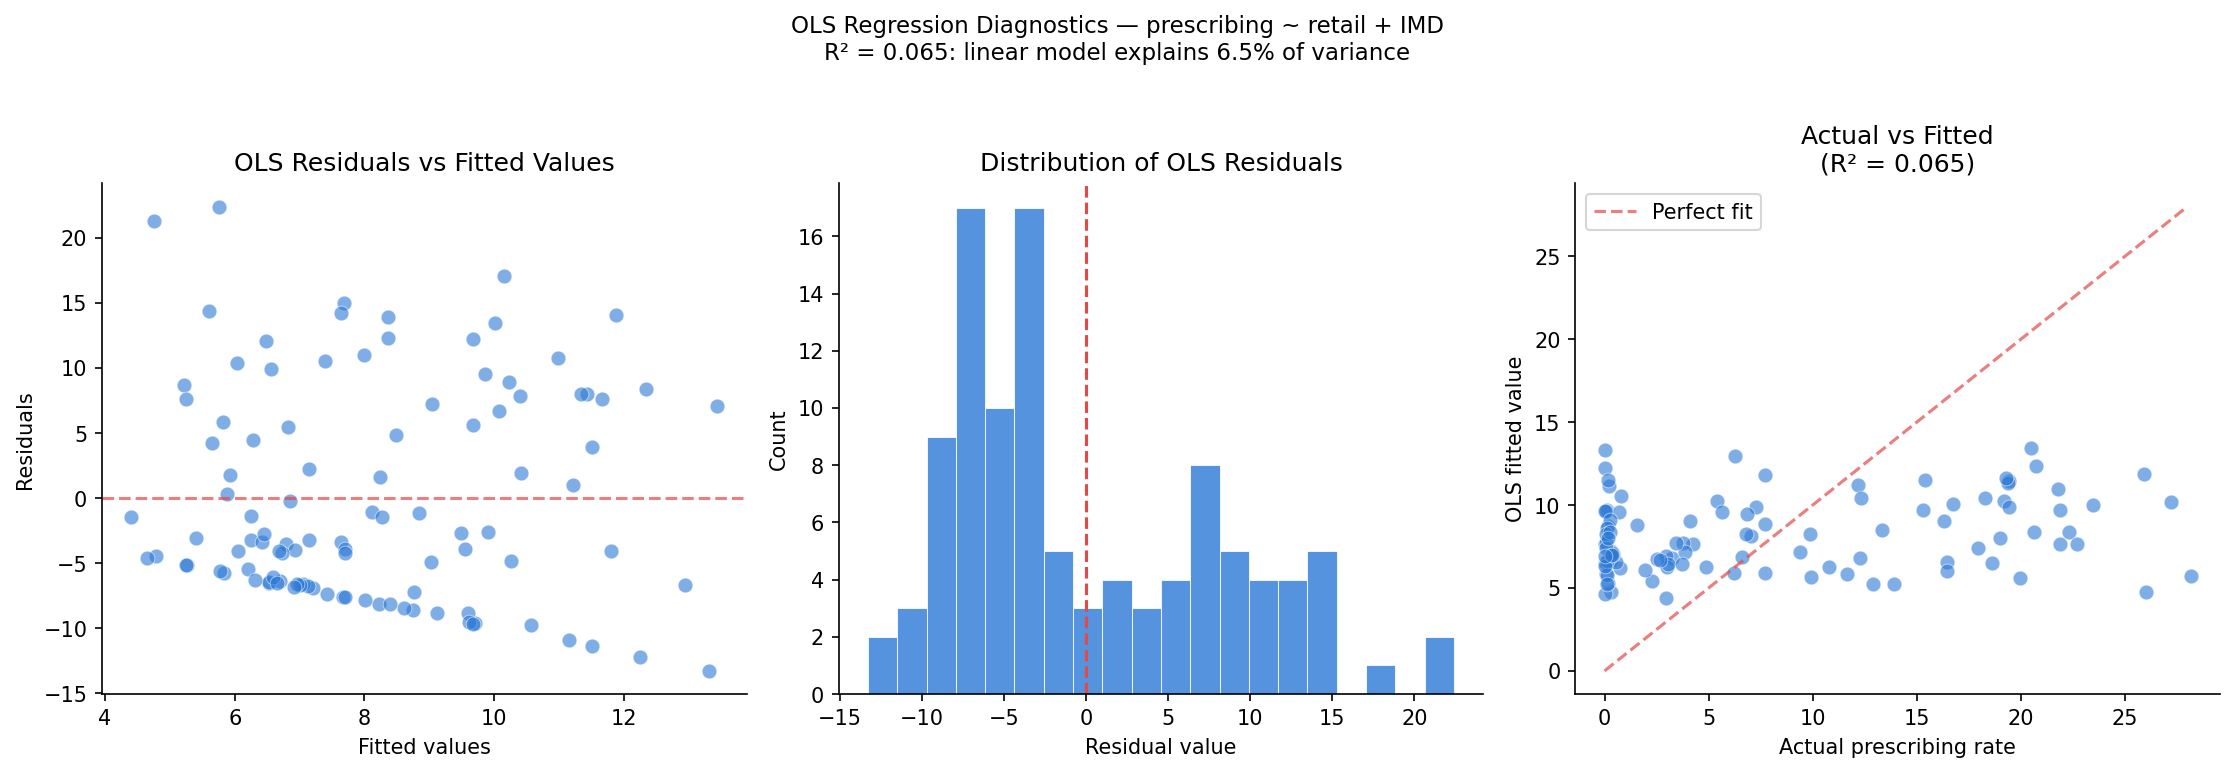

Saved CM_01.


In [2]:
# ── OLS RESIDUAL PLOT ─────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Fitted vs residuals
fitted = model.fittedvalues
residuals = model.resid

axes[0].scatter(fitted, residuals, color=BLUE, alpha=0.6,
                s=50, edgecolors='white', linewidth=0.4)
axes[0].axhline(0, color=RED, linewidth=1.5, linestyle='--', alpha=0.7)
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('OLS Residuals vs Fitted Values')

# Residual distribution
axes[1].hist(residuals, bins=20, color=BLUE, alpha=0.8,
             edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color=RED, linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Residual value')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of OLS Residuals')

# Actual vs fitted
axes[2].scatter(df['prescribing_rate_recent'], fitted,
                color=BLUE, alpha=0.6, s=50,
                edgecolors='white', linewidth=0.4)
axes[2].plot([0, 28], [0, 28], color=RED, linewidth=1.5,
             linestyle='--', alpha=0.7, label='Perfect fit')
axes[2].set_xlabel('Actual prescribing rate')
axes[2].set_ylabel('OLS fitted value')
axes[2].set_title(f'Actual vs Fitted\n(R² = {model.rsquared:.3f})')
axes[2].legend()

plt.suptitle('OLS Regression Diagnostics — prescribing ~ retail + IMD\n'
             'R² = 0.065: linear model explains 6.5% of variance',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/CM_01_OLS_diagnostics.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved CM_01.")

In [4]:
# ── MORAN'S I — SPATIAL AUTOCORRELATION ───────────────────────────────────
# Tests whether prescribing and retail cluster geographically
# Requires Sub-ICB centroid coordinates

# Get centroids from NSPL — average lat/lon of postcodes within each Sub-ICB
print("Loading NSPL for Sub-ICB centroids...")
nspl = pd.read_csv(
    r'C:\Users\namra\gluten-free-spatial-inequality\data\raw\nspl_may2026.csv',
    usecols=['pcds', 'lsoa21cd', 'sicbl26cd', 'lat', 'long'],
    low_memory=False
)
nspl = nspl[nspl['lsoa21cd'].str.startswith('E', na=False)]
nspl = nspl[nspl['lat'] != 0]

# Load LSOA to SICBL lookup for old CCG code
lookup = pd.read_csv(
    r'C:\Users\namra\gluten-free-spatial-inequality\data\raw\lsoa_to_sicbl_lookup.csv'
)
lookup_slim = lookup[['SICBL26CD', 'SICBL26CDH']].drop_duplicates()

# Join NSPL to get CCG code
nspl_joined = nspl.merge(lookup_slim, left_on='sicbl26cd',
                          right_on='SICBL26CD', how='left')
nspl_joined = nspl_joined.dropna(subset=['SICBL26CDH'])

# Compute centroid per Sub-ICB
centroids = nspl_joined.groupby('SICBL26CDH').agg(
    centroid_lat=('lat', 'mean'),
    centroid_lon=('long', 'mean')
).reset_index()
centroids.columns = ['org_id', 'centroid_lat', 'centroid_lon']

df = df.merge(centroids, on='org_id', how='left')
print(f"Centroids matched: {df['centroid_lat'].notna().sum()} of {len(df)}")
print(df[['org_name', 'centroid_lat', 'centroid_lon']].head(5))

Loading NSPL for Sub-ICB centroids...
Centroids matched: 106 of 106
                    org_name  centroid_lat  centroid_lon
0         NHS NORTHUMBERLAND     55.175415     -1.796314
1         NHS SOUTH TYNESIDE     54.973868     -1.449417
2             NHS SUNDERLAND     54.892461     -1.439096
3  NHS BLACKBURN WITH DARWEN     53.729119     -2.477177
4              NHS BLACKPOOL     53.817675     -3.038392


In [5]:
# ── MORAN'S I COMPUTATION ─────────────────────────────────────────────────
# Global spatial autocorrelation of prescribing and retail separately
# Using inverse distance spatial weights matrix

from scipy.spatial.distance import cdist

coords = df[['centroid_lat', 'centroid_lon']].values

# Build inverse distance weight matrix
dist_matrix = cdist(coords, coords, metric='euclidean')
np.fill_diagonal(dist_matrix, np.inf)  # no self-weight
W = 1 / dist_matrix
np.fill_diagonal(W, 0)

# Row-standardise
W_std = W / W.sum(axis=1, keepdims=True)

def morans_i(values, W):
    """Compute Global Moran's I statistic with permutation-based p-value."""
    n = len(values)
    z = values - values.mean()
    numerator = n * np.sum(W * np.outer(z, z))
    denominator = np.sum(W) * np.sum(z**2)
    I = numerator / denominator

    # Permutation test (999 permutations)
    np.random.seed(42)
    I_perm = []
    for _ in range(999):
        z_perm = np.random.permutation(z)
        num_p = n * np.sum(W * np.outer(z_perm, z_perm))
        I_perm.append(num_p / denominator)

    p_value = (np.sum(np.array(I_perm) >= I) + 1) / (999 + 1)
    z_score = (I - np.mean(I_perm)) / np.std(I_perm)
    return I, z_score, p_value, np.array(I_perm)

print("Computing Moran's I...")
print("="*55)

variables_morans = {
    'NHS GF Prescribing Rate': df['prescribing_rate_recent'].values,
    'GF Retail Accessibility': df['retail_accessibility_score'].values,
    'Area Deprivation (IMD)':  df['imd_score_weighted'].values,
    'Months Zero (Withdrawal)': df['months_zero'].values,
}

morans_results = {}
for name, vals in variables_morans.items():
    I, z, p, I_perm = morans_i(vals, W_std)
    morans_results[name] = {'I': I, 'z': z, 'p': p, 'I_perm': I_perm}
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f"{name}")
    print(f"  Moran's I = {I:.4f} | z = {z:.3f} | p = {p:.4f} {sig}")
    print()

print("Interpretation: I > 0 = clustered, I < 0 = dispersed, I ≈ 0 = random")
print("* p<0.05  ** p<0.01  *** p<0.001")

Computing Moran's I...
NHS GF Prescribing Rate
  Moran's I = 0.0792 | z = 5.874 | p = 0.0010 **

GF Retail Accessibility
  Moran's I = 0.0442 | z = 3.552 | p = 0.0040 **

Area Deprivation (IMD)
  Moran's I = 0.1115 | z = 8.248 | p = 0.0010 **

Months Zero (Withdrawal)
  Moran's I = 0.0539 | z = 4.390 | p = 0.0040 **

Interpretation: I > 0 = clustered, I < 0 = dispersed, I ≈ 0 = random
* p<0.05  ** p<0.01  *** p<0.001


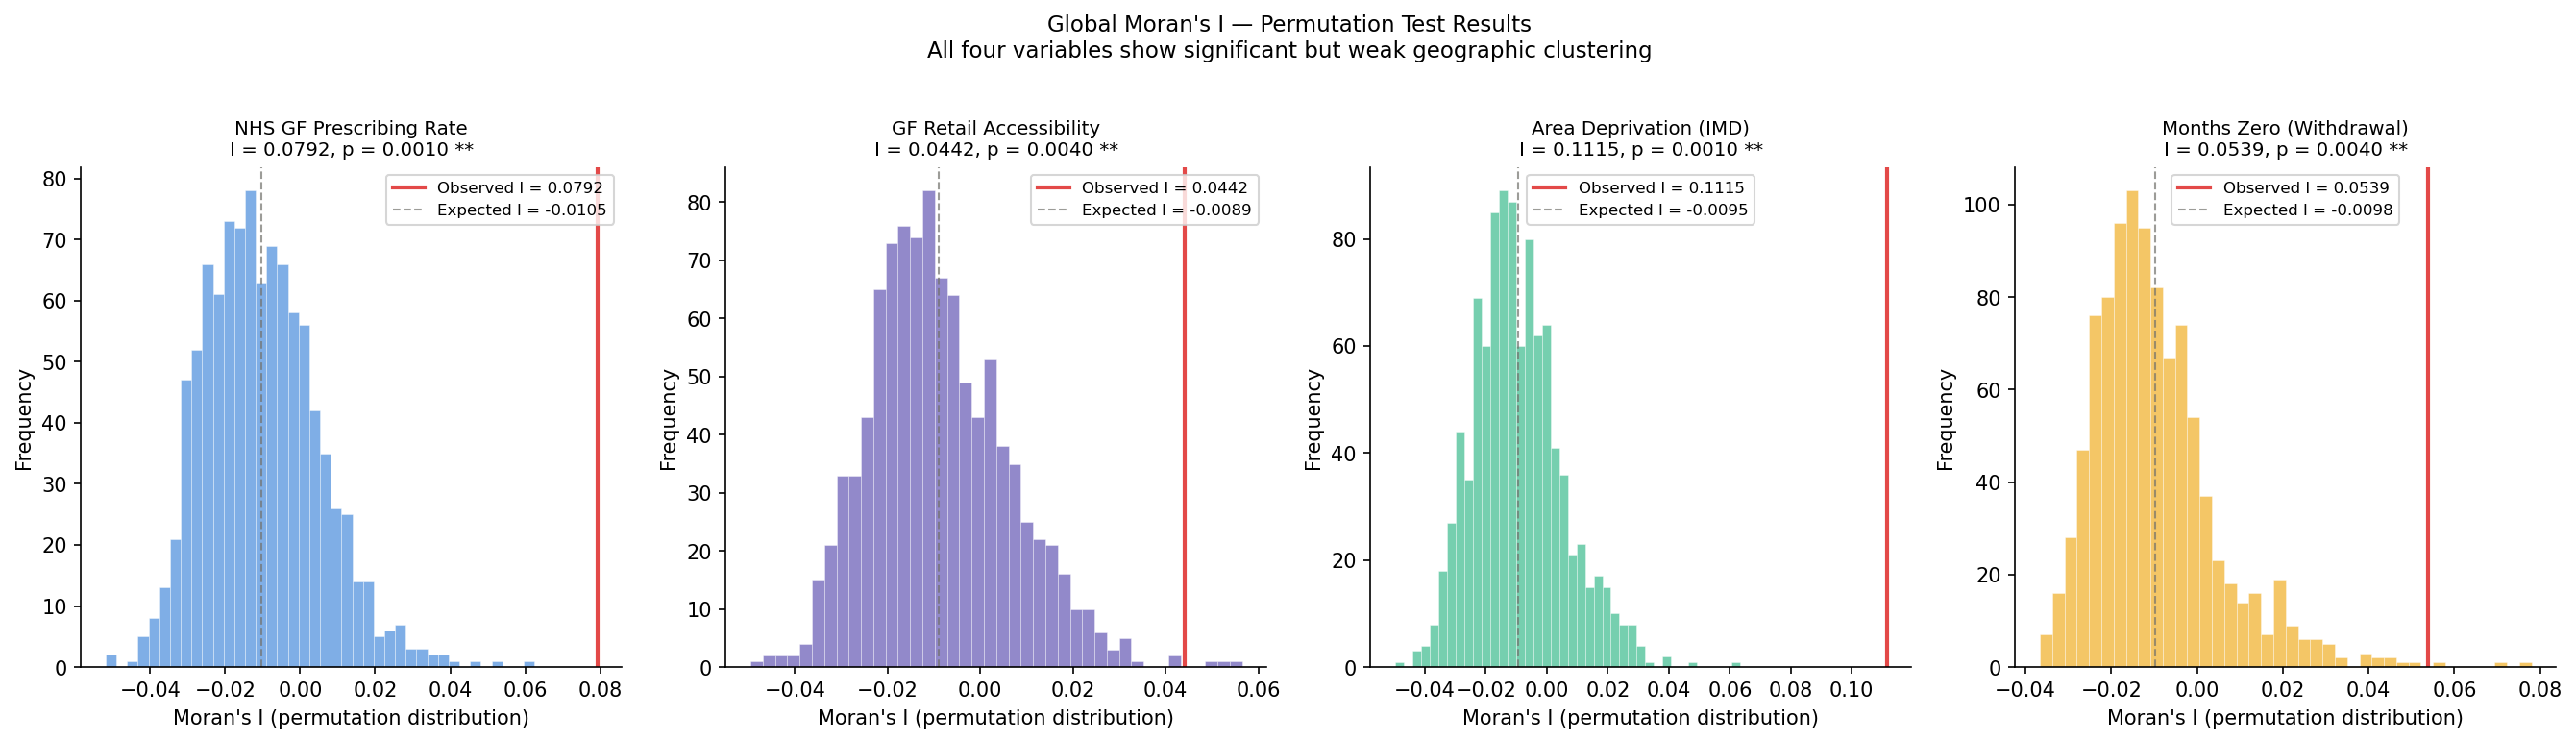

Saved CM_02.


In [6]:
# ── MORAN'S I VISUALISATION ───────────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

var_names = list(morans_results.keys())
colors_m = [BLUE, PURPLE, GREEN, AMBER]

for ax, name, color in zip(axes, var_names, colors_m):
    res = morans_results[name]
    I_perm = res['I_perm']
    I_obs  = res['I']

    ax.hist(I_perm, bins=40, color=color, alpha=0.6,
            edgecolor='white', linewidth=0.3)
    ax.axvline(I_obs, color=RED, linewidth=2, linestyle='-',
               label=f"Observed I = {I_obs:.4f}")
    ax.axvline(np.mean(I_perm), color=GREY, linewidth=1,
               linestyle='--', alpha=0.7,
               label=f"Expected I = {np.mean(I_perm):.4f}")

    sig = '**' if res['p'] < 0.01 else ('*' if res['p'] < 0.05 else '')
    ax.set_title(f"{name}\nI = {I_obs:.4f}, p = {res['p']:.4f} {sig}",
                 fontsize=9.5)
    ax.set_xlabel("Moran's I (permutation distribution)")
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.suptitle("Global Moran's I — Permutation Test Results\n"
             "All four variables show significant but weak geographic clustering",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/CM_02_morans_i.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved CM_02.")

In [7]:
# ── K-MEANS CLUSTERING ────────────────────────────────────────────────────
# k=7 in same 3D scaled space as Ball Mapper
# Direct comparison of cluster membership vs Ball Mapper nodes

from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances
import networkx as nx

# Rebuild Ball Mapper for comparison
def ball_mapper(X, epsilon):
    n = X.shape[0]
    dist = euclidean_distances(X)
    covered = np.zeros(n, dtype=bool)
    nodes = {}
    nid = 0
    for i in range(n):
        if not covered[i]:
            members = np.where(dist[i] <= epsilon)[0].tolist()
            nodes[nid] = members
            for j in members:
                covered[j] = True
            nid += 1
    edges = []
    ids = list(nodes.keys())
    for a in range(len(ids)):
        for b in range(a + 1, len(ids)):
            if set(nodes[ids[a]]) & set(nodes[ids[b]]):
                edges.append((ids[a], ids[b]))
    return nodes, edges

def primary_node_partition(nodes, n_points):
    labels = np.full(n_points, -1)
    for nid, members in nodes.items():
        for m in members:
            if labels[m] == -1:
                labels[m] = nid
    return labels

variables = ['prescribing_rate_recent', 'retail_accessibility_score', 'imd_score_weighted']
X_raw    = df[variables].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

nodes, edges = ball_mapper(X_scaled, 2.0)
bm_labels = primary_node_partition(nodes, len(df))

# K-means with k=7
kmeans = KMeans(n_clusters=7, random_state=42, n_init=50)
km_labels = kmeans.fit_predict(X_scaled)

# ARI between k-means and Ball Mapper
ari_km_bm = adjusted_rand_score(bm_labels, km_labels)
print(f"ARI between k-means (k=7) and Ball Mapper (ε=2.0): {ari_km_bm:.4f}")

# K-means cluster summary
df['kmeans_cluster'] = km_labels
km_summary = df.groupby('kmeans_cluster').agg(
    areas=('org_id', 'count'),
    mean_prescribing=('prescribing_rate_recent', 'mean'),
    mean_retail=('retail_accessibility_score', 'mean'),
    mean_imd=('imd_score_weighted', 'mean'),
    mean_months_zero=('months_zero', 'mean'),
    mean_slope=('trend_slope', 'mean')
).round(3)

print("\nK-means cluster summary (k=7):")
print(km_summary.to_string())

km_summary.to_csv(f'{TAB_PATH}/kmeans_cluster_summary.csv')
print("\nSaved k-means summary.")

  File "C:\Users\namra\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\namra\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\namra\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\namra\anaconda3\Lib\subprocess.

ARI between k-means (k=7) and Ball Mapper (ε=2.0): 0.2592

K-means cluster summary (k=7):
                areas  mean_prescribing  mean_retail  mean_imd  mean_months_zero  mean_slope
kmeans_cluster                                                                              
0                  15             2.244        0.256    31.645            13.000      -0.094
1                  15            17.774        0.290    16.674             0.200       0.004
2                  14            20.815        0.247    30.963             0.000       0.072
3                  25             1.125        0.294    17.970             6.680      -0.052
4                  11             5.640        0.374    18.306             2.091       0.008
5                  18             3.076        0.223    19.704             3.278      -0.033
6                   8            15.576        0.342    32.291             0.000      -0.008

Saved k-means summary.


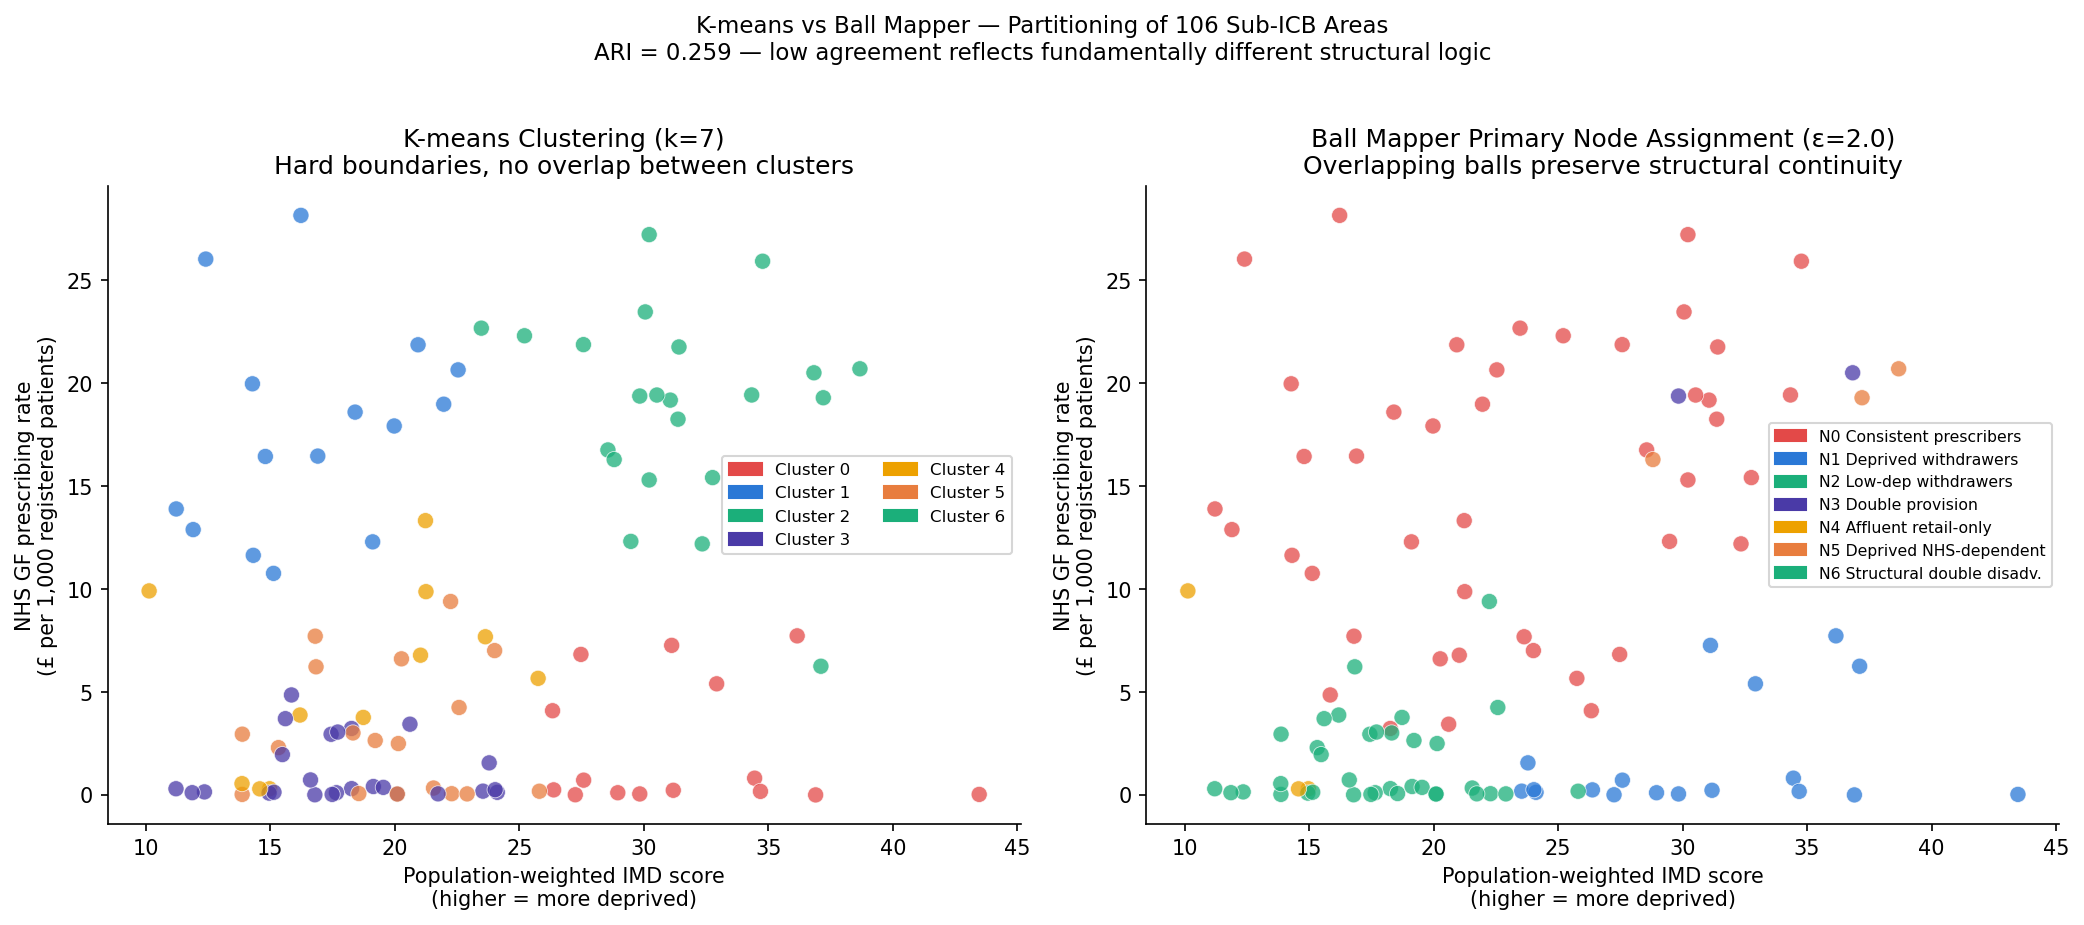

Saved CM_03.


In [8]:
# ── K-MEANS vs BALL MAPPER COMPARISON PLOT ────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: scatter coloured by k-means cluster
colors_km = [RED, BLUE, GREEN, PURPLE, AMBER, '#e87d3e', '#1baf7a']
km_color_vals = [colors_km[c] for c in df['kmeans_cluster']]

axes[0].scatter(df['imd_score_weighted'], df['prescribing_rate_recent'],
                c=km_color_vals, alpha=0.75, s=60,
                edgecolors='white', linewidth=0.4)
axes[0].set_xlabel('Population-weighted IMD score\n(higher = more deprived)')
axes[0].set_ylabel('NHS GF prescribing rate\n(£ per 1,000 registered patients)')
axes[0].set_title(f'K-means Clustering (k=7)\nHard boundaries, no overlap between clusters')
handles_km = [mpatches.Patch(color=colors_km[i], label=f'Cluster {i}')
              for i in range(7)]
axes[0].legend(handles=handles_km, fontsize=8, ncol=2)

# Right: scatter coloured by Ball Mapper primary node
bm_colors = [RED, BLUE, GREEN, PURPLE, AMBER, '#e87d3e', '#1baf7a']
node_labels_short = {
    0: 'N0 Consistent prescribers',
    1: 'N1 Deprived withdrawers',
    2: 'N2 Low-dep withdrawers',
    3: 'N3 Double provision',
    4: 'N4 Affluent retail-only',
    5: 'N5 Deprived NHS-dependent',
    6: 'N6 Structural double disadv.'
}
bm_color_vals = [bm_colors[l] for l in bm_labels]

axes[1].scatter(df['imd_score_weighted'], df['prescribing_rate_recent'],
                c=bm_color_vals, alpha=0.75, s=60,
                edgecolors='white', linewidth=0.4)
axes[1].set_xlabel('Population-weighted IMD score\n(higher = more deprived)')
axes[1].set_ylabel('NHS GF prescribing rate\n(£ per 1,000 registered patients)')
axes[1].set_title(f'Ball Mapper Primary Node Assignment (ε=2.0)\n'
                  f'Overlapping balls preserve structural continuity')
handles_bm = [mpatches.Patch(color=bm_colors[i], label=node_labels_short[i])
              for i in range(7)]
axes[1].legend(handles=handles_bm, fontsize=7.5, ncol=1)

plt.suptitle(f'K-means vs Ball Mapper — Partitioning of 106 Sub-ICB Areas\n'
             f'ARI = {ari_km_bm:.3f} — low agreement reflects fundamentally different structural logic',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/CM_03_kmeans_vs_ballmapper.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved CM_03.")